In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier


from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv('/content/drive/MyDrive/AIML_LAB/Exp11&12/dataset_Melbourne_housing_FULL_exp_12.csv')

print("First 5 rows of the dataset:")
display(df.head())


print("\nInformation about the dataset:")
display(df.info())

First 5 rows of the dataset:


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,68 Studley St,2,h,NaN,SS,Jellis,3/09/2016,2.5,3067.0,...,1.0,1.0,126.0,NaN,NaN,Yarra City Council,-37.8014,144.9958,Northern Metropolitan,4019.0
1,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra City Council,-37.7996,144.9984,Northern Metropolitan,4019.0
2,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra City Council,-37.8079,144.9934,Northern Metropolitan,4019.0
3,Abbotsford,18/659 Victoria St,3,u,NaN,VB,Rounds,4/02/2016,2.5,3067.0,...,2.0,1.0,0.0,NaN,NaN,Yarra City Council,-37.8114,145.0116,Northern Metropolitan,4019.0
4,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra City Council,-37.8093,144.9944,Northern Metropolitan,4019.0



Information about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34857 entries, 0 to 34856
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         34857 non-null  object 
 1   Address        34857 non-null  object 
 2   Rooms          34857 non-null  int64  
 3   Type           34857 non-null  object 
 4   Price          27247 non-null  float64
 5   Method         34857 non-null  object 
 6   SellerG        34857 non-null  object 
 7   Date           34857 non-null  object 
 8   Distance       34856 non-null  float64
 9   Postcode       34856 non-null  float64
 10  Bedroom2       26640 non-null  float64
 11  Bathroom       26631 non-null  float64
 12  Car            26129 non-null  float64
 13  Landsize       23047 non-null  float64
 14  BuildingArea   13742 non-null  float64
 15  YearBuilt      15551 non-null  float64
 16  CouncilArea    34854 non-null  object 
 17  Lattitude      268

None

In [3]:
df = df.drop(['Address', 'Date'], axis=1)

for col in df.select_dtypes(include=['float64', 'int64']).columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mean())

for col in df.select_dtypes(include=['object']).columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])

df_processed = pd.get_dummies(df, drop_first=True)

print("First 5 rows of the processed dataset:")
display(df_processed.head())

print("\nInformation about the processed dataset:")
display(df_processed.info())

First 5 rows of the processed dataset:


,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,...,CouncilArea_Wyndham City Council,CouncilArea_Yarra City Council,CouncilArea_Yarra Ranges Shire Council,Regionname_Eastern Victoria,Regionname_Northern Metropolitan,Regionname_Northern Victoria,Regionname_South-Eastern Metropolitan,Regionname_Southern Metropolitan,Regionname_Western Metropolitan,Regionname_Western Victoria
0,2,1.050173e+06,2.5,3067.0,2.0,1.0,1.0,126.0,160.2564,1965.289885,...,False,True,False,False,True,False,False,False,False,False
1,2,1.480000e+06,2.5,3067.0,2.0,1.0,1.0,202.0,160.2564,1965.289885,...,False,True,False,False,True,False,False,False,False,False
2,2,1.035000e+06,2.5,3067.0,2.0,1.0,0.0,156.0,79.0000,1900.000000,...,False,True,False,False,True,False,False,False,False,False
3,3,1.050173e+06,2.5,3067.0,3.0,2.0,1.0,0.0,160.2564,1965.289885,...,False,True,False,False,True,False,False,False,False,False
4,3,1.465000e+06,2.5,3067.0,3.0,2.0,0.0,134.0,150.0000,1900.000000,...,False,True,False,False,True,False,False,False,False,False



Information about the processed dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34857 entries, 0 to 34856
Columns: 799 entries, Rooms to Regionname_Western Victoria
dtypes: bool(786), float64(12), int64(1)
memory usage: 29.6 MB


None

In [4]:
from sklearn.model_selection import train_test_split

X = df_processed.drop('Price', axis=1)
y = df_processed['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (27885, 798)
Shape of X_test: (6972, 798)
Shape of y_train: (27885,)
Shape of y_test: (6972,)


In [5]:
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

lasso_model = Lasso(alpha=0.1, random_state=42)

lasso_model.fit(X_train, y_train)

y_train_pred_lasso = lasso_model.predict(X_train)
y_test_pred_lasso = lasso_model.predict(X_test)

r2_train_lasso = r2_score(y_train, y_train_pred_lasso)
mse_train_lasso = mean_squared_error(y_train, y_train_pred_lasso)
r2_test_lasso = r2_score(y_test, y_test_pred_lasso)
mse_test_lasso = mean_squared_error(y_test, y_test_pred_lasso)
rmse_test_lasso = np.sqrt(mse_test_lasso)

print("Lasso Regression Performance:")
print(f"  Training R-squared: {r2_train_lasso:.4f}")
print(f"  Training MSE: {mse_train_lasso:.2f}")
print(f"  Testing R-squared: {r2_test_lasso:.4f}")
print(f"  Testing MSE: {mse_test_lasso:.2f}")
print(f"  Testing RMSE: {rmse_test_lasso:.2f}")

print(f"\nNumber of features selected by Lasso (non-zero coefficients): {np.sum(lasso_model.coef_ != 0)}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.288e+15, tolerance: 9.144e+11
  model = cd_fast.enet_coordinate_descent(


Lasso Regression Performance:
  Training R-squared: 0.4996
  Training MSE: 164104564000.75
  Testing R-squared: 0.4100
  Testing MSE: 174732844839.01
  Testing RMSE: 418010.58

Number of features selected by Lasso (non-zero coefficients): 767


In [6]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0, random_state=42)

ridge_model.fit(X_train, y_train)

y_train_pred_ridge = ridge_model.predict(X_train)
y_test_pred_ridge = ridge_model.predict(X_test)

r2_train_ridge = r2_score(y_train, y_train_pred_ridge)
mse_train_ridge = mean_squared_error(y_train, y_train_pred_ridge)
r2_test_ridge = r2_score(y_test, y_test_pred_ridge)
mse_test_ridge = mean_squared_error(y_test, y_test_pred_ridge)
rmse_test_ridge = np.sqrt(mse_test_ridge)

print("Ridge Regression Performance:")
print(f"  Training R-squared: {r2_train_ridge:.4f}")
print(f"  Training MSE: {mse_train_ridge:.2f}")
print(f"  Testing R-squared: {r2_test_ridge:.4f}")
print(f"  Testing MSE: {mse_test_ridge:.2f}")
print(f"  Testing RMSE: {rmse_test_ridge:.2f}")

print(f"\nNumber of features selected by Ridge (non-zero coefficients): {np.sum(ridge_model.coef_ != 0)}")

Ridge Regression Performance:
  Training R-squared: 0.4989
  Training MSE: 164315976903.90
  Testing R-squared: 0.4118
  Testing MSE: 174179644145.25
  Testing RMSE: 417348.35

Number of features selected by Ridge (non-zero coefficients): 769


In [7]:
print("\n--- Comparison of Lasso vs. Ridge Regression ---")
print("\nLasso Regression Performance:")
print(f"  Training R-squared: {r2_train_lasso:.4f}")
print(f"  Training MSE: {mse_train_lasso:.2f}")
print(f"  Testing R-squared: {r2_test_lasso:.4f}")
print(f"  Testing MSE: {mse_test_lasso:.2f}")
print(f"  Testing RMSE: {rmse_test_lasso:.2f}")
print(f"  Features selected (non-zero coefficients): {np.sum(lasso_model.coef_ != 0)}")

print("\nRidge Regression Performance:")
print(f"  Training R-squared: {r2_train_ridge:.4f}")
print(f"  Training MSE: {mse_train_ridge:.2f}")
print(f"  Testing R-squared: {r2_test_ridge:.4f}")
print(f"  Testing MSE: {mse_test_ridge:.2f}")
print(f"  Testing RMSE: {rmse_test_ridge:.2f}")
print(f"  Features selected (non-zero coefficients): {np.sum(ridge_model.coef_ != 0)}")
print("\n--- Observations ---")
if r2_test_lasso > r2_test_ridge:
    print("Lasso Regression has a slightly higher Testing R-squared.")
elif r2_test_ridge > r2_test_lasso:
    print("Ridge Regression has a slightly higher Testing R-squared.")
else:
    print("Both models have similar Testing R-squared values.")

if rmse_test_lasso < rmse_test_ridge:
    print("Lasso Regression has a slightly lower Testing RMSE.")
elif rmse_test_ridge < rmse_test_lasso:
    print("Ridge Regression has a slightly lower Testing RMSE.")
else:
    print("Both models have similar Testing RMSE values.")

print(f"Lasso selected {np.sum(lasso_model.coef_ != 0)} features, while Ridge used {np.sum(ridge_model.coef_ != 0)} features. This highlights Lasso's feature selection capability.")


--- Comparison of Lasso vs. Ridge Regression ---

Lasso Regression Performance:
  Training R-squared: 0.4996
  Training MSE: 164104564000.75
  Testing R-squared: 0.4100
  Testing MSE: 174732844839.01
  Testing RMSE: 418010.58
  Features selected (non-zero coefficients): 767

Ridge Regression Performance:
  Training R-squared: 0.4989
  Training MSE: 164315976903.90
  Testing R-squared: 0.4118
  Testing MSE: 174179644145.25
  Testing RMSE: 417348.35
  Features selected (non-zero coefficients): 769

--- Observations ---
Ridge Regression has a slightly higher Testing R-squared.
Ridge Regression has a slightly lower Testing RMSE.
Lasso selected 767 features, while Ridge used 769 features. This highlights Lasso's feature selection capability.


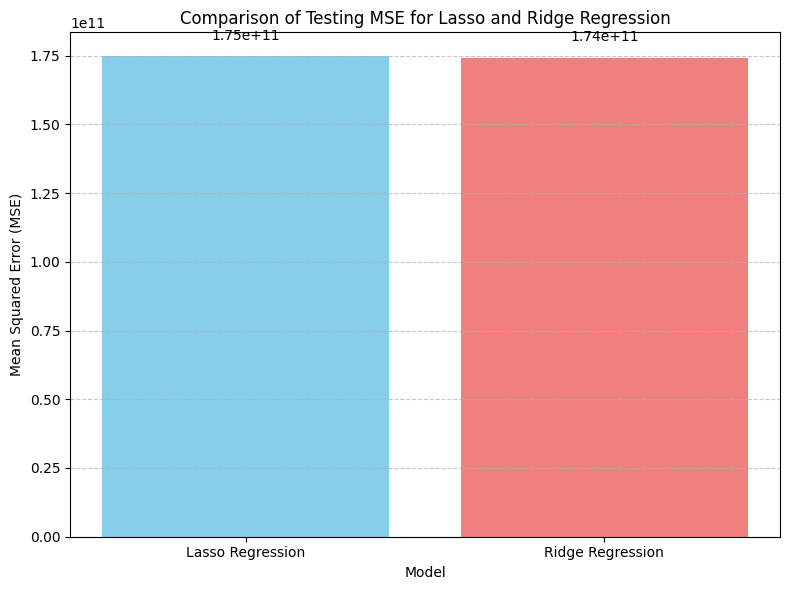

In [8]:
import matplotlib.pyplot as plt

# Data for plotting
models = ['Lasso Regression', 'Ridge Regression']
mse_values = [mse_test_lasso, mse_test_ridge]

# Create the bar plot
plt.figure(figsize=(8, 6))
plt.bar(models, mse_values, color=['skyblue', 'lightcoral'])

# Add title and labels
plt.title('Comparison of Testing MSE for Lasso and Ridge Regression')
plt.xlabel('Model')
plt.ylabel('Mean Squared Error (MSE)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the MSE values on top of the bars
for i, mse in enumerate(mse_values):
    plt.text(i, mse + 5000000000, f'{mse:.2e}', ha='center', va='bottom')

plt.tight_layout()
plt.show()


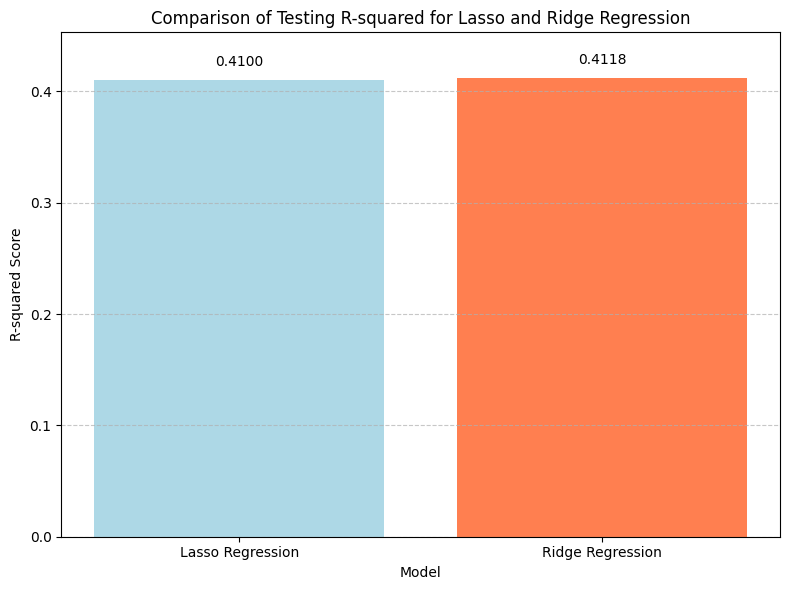

In [9]:
import matplotlib.pyplot as plt

models = ['Lasso Regression', 'Ridge Regression']
r2_values = [r2_test_lasso, r2_test_ridge]

plt.figure(figsize=(8, 6))
plt.bar(models, r2_values, color=['lightblue', 'coral'])

plt.title('Comparison of Testing R-squared for Lasso and Ridge Regression')
plt.xlabel('Model')
plt.ylabel('R-squared Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, r2 in enumerate(r2_values):
    plt.text(i, r2 + 0.01, f'{r2:.4f}', ha='center', va='bottom')

plt.ylim(0, max(r2_values) * 1.1)
plt.tight_layout()
plt.show()

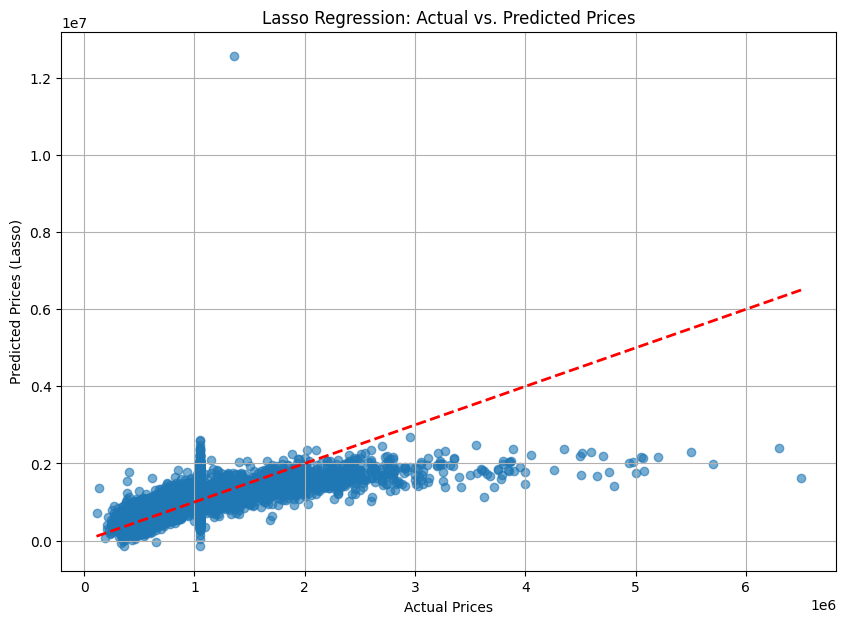

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
plt.scatter(y_test, y_test_pred_lasso, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Ideal line
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices (Lasso)')
plt.title('Lasso Regression: Actual vs. Predicted Prices')
plt.grid(True)
plt.show()

In [11]:
import pickle

with open('lasso_model.pkl', 'wb') as f:
    pickle.dump(lasso_model, f)

with open('ridge_model.pkl', 'wb') as f:
    pickle.dump(ridge_model, f)


print("Models saved successfully!")

Models saved successfully!
